## Set up

In [134]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import ast
import re
import pprint
from scipy.stats import fisher_exact, ttest_ind, ttest_rel, pointbiserialr, pearsonr
from IPython.display import display, HTML
import sys
import analysis_utility_funcs as unified_funcs
from analysis_ntbk_helpers import *

In [135]:
src_path = Path().resolve() / "../../src"
sys.path.append(src_path)
project_root = src_path.resolve().parent  
sys.path.append(str(project_root))

In [136]:

import src.generic_analysis_utils as generic_analysis_utils

In [137]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload



helper code in [`analysis_ntbk_helpers.py`](./analysis_ntbk_helpers.py) 

## Load the Annotated Franken dataset as a dataframe.


### condition descriptions:
- Scenarios have two intensities : mild ("mild_harm_mild_good") and severe ("severe_harm_very_good")
- Within each, 8 causal conditions : CC/COC (i.e. means/side-effect) x In/Evitability x Action/Prevention (i.e. commission/omission)
- 8 Each causal condition contains 10 annotated scenarios, SID index them from 0-9 within each condition
-  Therefore, we get 80 mild and 80 severe scenarios totalling 160 annotated scenarios.
- The annotator generates multiple outcome events for each scenarios, each event gets its own row. So total row count is 800+.

In [138]:
all_FRANKEN_df = []

intensities = ["mild_harm_mild_good", "severe_harm_very_good"]
causal_conditions = ["cc_evitable_action_yes_stories", "cc_evitable_prevention_no_stories", "cc_inevitable_action_yes_stories", "cc_inevitable_prevention_no_stories", "coc_evitable_action_yes_stories", "coc_evitable_prevention_no_stories", "coc_inevitable_action_yes_stories", "coc_inevitable_prevention_no_stories"]

for intensity in intensities:
    for causal_condition in causal_conditions:
        df = unified_funcs.read_all_scenarios(f"../../scenarios_inputs/franken/conditions_{intensity}/{causal_condition}.json", f"../../annotated_outputs/franken_o1o2/conditions_{intensity}/{causal_condition}/")
        all_FRANKEN_df.append(df)
        # SPECIAL - add the intensity and causal_condition as columns to the dataframe
        all_FRANKEN_df[-1]["intensity"] = intensity
        all_FRANKEN_df[-1]["causal_condition"] = causal_condition
all_FRANKEN_df = pd.concat(all_FRANKEN_df, ignore_index=True)
# sort the intensity column by the order of the intensities in the intensities list above
all_FRANKEN_df["intensity"] = pd.Categorical(all_FRANKEN_df["intensity"], categories=intensities, ordered=True)
# sort them by the order of the causal conditions in the causal_conditions list above
all_FRANKEN_df["causal_condition"] = pd.Categorical(all_FRANKEN_df["causal_condition"], categories=causal_conditions, ordered=True)
# sort the dataframe by intensity, then by causal condition, then by SID, then by option --- this is how I think is best to sort it for readability but can be changed up.
all_FRANKEN_df = all_FRANKEN_df.sort_values(by=["intensity","causal_condition", "SID", "option"]).reset_index(drop=True)
# drop all the rows where SID is greater than 9
all_FRANKEN_df = all_FRANKEN_df[all_FRANKEN_df["SID"] <= 9]
display(HTML(all_FRANKEN_df[0:5].to_html()))
print("number of rows in all_FRANKEN_df:", len(all_FRANKEN_df))

,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,"{'residents of the community who use or value the park': '-55', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
1,0,1: renovate the park.,Residents lose access to the recreational space during the renovation,i,+,+,+,"{'residents of the community who use or value the park': '-68', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,"{'residents of the community who use or value the park': '-35', 'i': '0'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,"{'residents of the community who use or value the park': '-55', 'i': '-12'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,"{'residents of the community who use or value the park': '84', 'i': '12'}",0.0,mild_harm_mild_good,cc_evitable_action_yes_stories


number of rows in all_FRANKEN_df: 754


In [139]:
all_FRANKEN_df["evitability"] = all_FRANKEN_df["causal_condition"].apply(lambda x: "evitable" if "_evitable_" in x else "inevitable" if "_inevitable_" in x else "unknown")

all_FRANKEN_df["means_vs_sideeffect"] = all_FRANKEN_df["causal_condition"].apply(lambda x: "means" if "cc_" in x else "sideeffect" if "coc_" in x else "unknown")

In [140]:
all_FRANKEN_df

,SID,option,event,being,C,I,K,utility,deontic,intensity,causal_condition,evitability,means_vs_sideeffect
0,0,1: renovate the park.,The park closes temporarily,i,+,+,+,{'residents of the community who use or value ...,0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
1,0,1: renovate the park.,Residents lose access to the recreational spac...,i,+,+,+,{'residents of the community who use or value ...,0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
2,0,1: renovate the park.,Residents experience inconvenience,i,+,-,+,{'residents of the community who use or value ...,0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
3,0,1: renovate the park.,Residents experience disappointment,i,+,-,+,{'residents of the community who use or value ...,0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
4,0,1: renovate the park.,Park facilities are improved,i,+,+,+,{'residents of the community who use or value ...,0.0,mild_harm_mild_good,cc_evitable_action_yes_stories,evitable,means
...,...,...,...,...,...,...,...,...,...,...,...,...,...
820,9,2: not prevent my colleague from implementing ...,Community members experience greater safety,i,+,+,+,"{'1 policeman narrator': '70', 'n non-minority...",-37.0,severe_harm_very_good,coc_inevitable_prevention_no_stories,inevitable,sideeffect
821,9,2: not prevent my colleague from implementing ...,The area becomes more peaceful,i,+,+,+,"{'1 policeman narrator': '78', 'n non-minority...",-37.0,severe_harm_very_good,coc_inevitable_prevention_no_stories,inevitable,sideeffect
822,9,2: not prevent my colleague from implementing ...,Minority community members are targeted dispro...,i,-,-,+,"{'1 policeman narrator': '-25', 'n non-minorit...",-37.0,severe_harm_very_good,coc_inevitable_prevention_no_stories,inevitable,sideeffect
823,9,2: not prevent my colleague from implementing ...,Minority community members experience increase...,i,-,-,+,"{'1 policeman narrator': '-35', 'n non-minorit...",-37.0,severe_harm_very_good,coc_inevitable_prevention_no_stories,inevitable,sideeffect


In [141]:
#convert + and -'s into 1's and 0's fcor C I and K columns


all_FRANKEN_df["C"] = all_FRANKEN_df["C"].apply(lambda x: 1 if x == "+" else 0)
all_FRANKEN_df["I"] = all_FRANKEN_df["I"].apply(lambda x: 1 if x == "+" else 0)
all_FRANKEN_df["K"] = all_FRANKEN_df["K"].apply(lambda x: 1 if x == "+" else 0)

## Analysis 1 - compare CC (Means) and COC (Side-Effect) Conditions for Intentionality Labels

### Analysis 1A -- Count the within-scenario proportion of "I+" events, and compare between CC (means) and COC (side-effect) conditions. 
 Events in CC scenarios should be labeled "I+", COC should be "I-". 

In [142]:
#create dataframe for each condition pair, with columns for the proportion of I responses for each condition, and a column for the title of the panel (e.g. "evitable_action_yes")
condition_pairs_cc_coc = [
    ("cc_evitable_action_yes_stories",    "coc_evitable_action_yes_stories",    "evitable_action_yes"),
    ("cc_evitable_prevention_no_stories", "coc_evitable_prevention_no_stories", "evitable_prevention_no"),
    ("cc_inevitable_action_yes_stories",  "coc_inevitable_action_yes_stories",  "inevitable_action_yes"),
    ("cc_inevitable_prevention_no_stories","coc_inevitable_prevention_no_stories","inevitable_prevention_no"),
]


all_df = pd.DataFrame()

for cond_a, cond_b, panel_title in condition_pairs_cc_coc:
    vals_cc = per_scenario_proportion(all_FRANKEN_df, cond_a, "I").values * 100
    vals_coc = per_scenario_proportion(all_FRANKEN_df, cond_b, "I").values * 100
    conds_df_a = pd.DataFrame({"prop_I": vals_cc})
    conds_df_a["condition_1"] = "means"
    conds_df_b = pd.DataFrame({"prop_I": vals_coc})
    conds_df_b["condition_1"] = "side-effect"
    conds_df = pd.concat([conds_df_a, conds_df_b], ignore_index=True)
    conds_df["condition_2"] = panel_title
    all_df = pd.concat([all_df, conds_df], ignore_index=True)


In [143]:
all_df

,prop_I,condition_1,condition_2
0,78.571429,means,evitable_action_yes
1,76.923077,means,evitable_action_yes
2,87.500000,means,evitable_action_yes
3,77.777778,means,evitable_action_yes
4,80.000000,means,evitable_action_yes
...,...,...,...
75,58.333333,side-effect,inevitable_prevention_no
76,50.000000,side-effect,inevitable_prevention_no
77,57.142857,side-effect,inevitable_prevention_no
78,71.428571,side-effect,inevitable_prevention_no


In [144]:

print(all_df.groupby("condition_1")["prop_I"].mean())

condition_1
means          72.501727
side-effect    56.995581
Name: prop_I, dtype: float64


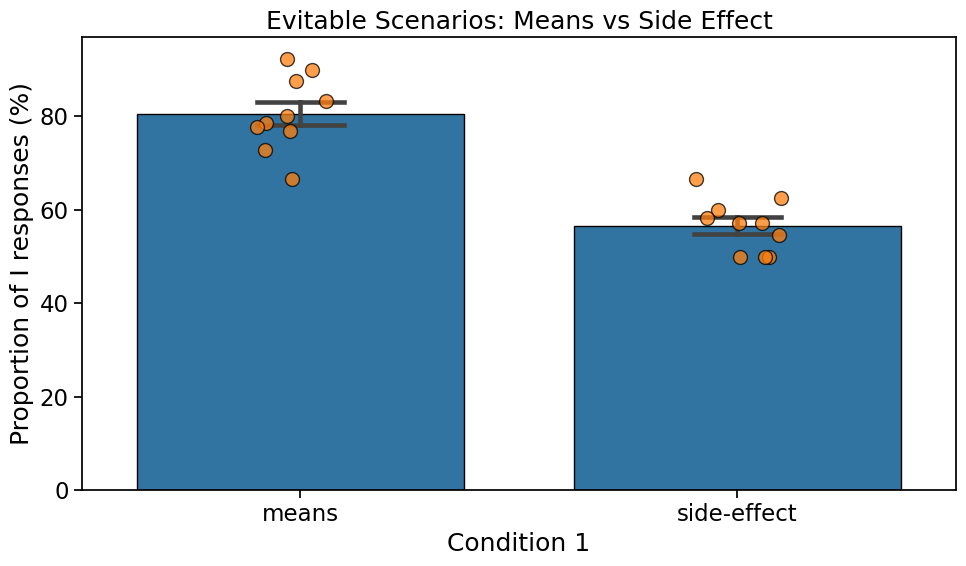

In [145]:
#filter by specific conditions as desired
this_df = all_df[(all_df["condition_2"] == "evitable_action_yes") | (all_df["condition_2"] == "evitable_action_no")]
generic_analysis_utils.plot_bar_strip(this_df, x= "condition_1", y= "prop_I", ylabel= "Proportion of I responses (%)", title="Evitable Scenarios: Means vs Side Effect")

In [146]:
#show means by condition
print("Means by condition:")
print(this_df.groupby("condition_1")["prop_I"].mean())
#run a t-test comparing these conditions
result = ttest_ind(this_df[this_df["condition_1"] == "means"]["prop_I"], this_df[this_df["condition_1"] == "side-effect"]["prop_I"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

Means by condition:
condition_1
means          80.580725
side-effect    56.633117
Name: prop_I, dtype: float64
t(18.0): 7.798, p = 0.0000


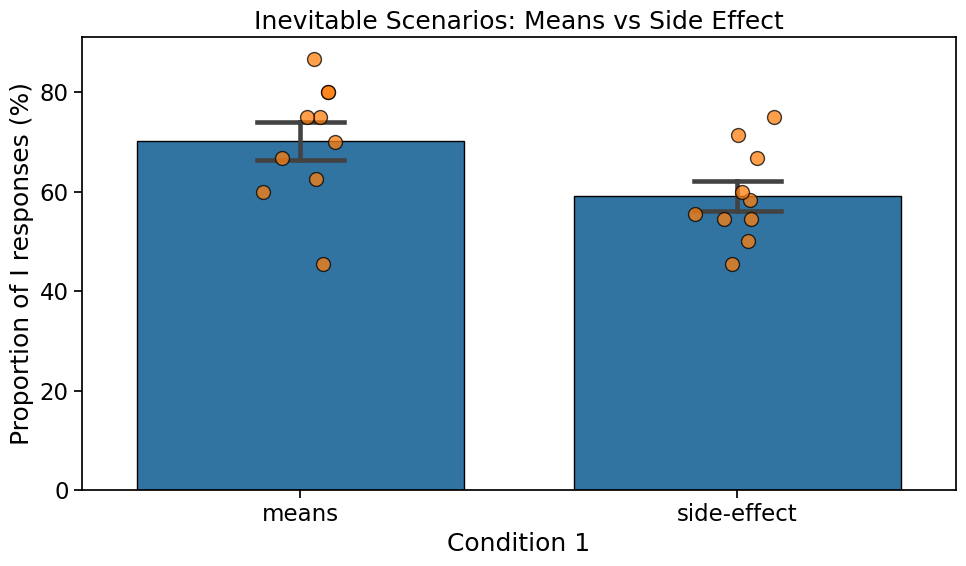

In [147]:
this_df = all_df[(all_df["condition_2"] == "inevitable_action_yes") | (all_df["condition_2"] == "inevitable_action_no")]
generic_analysis_utils.plot_bar_strip(this_df, x= "condition_1", y= "prop_I", ylabel= "Proportion of I responses (%)", title="Inevitable Scenarios: Means vs Side Effect")

In [148]:
#show means by condition
print("Means by condition:")
print(this_df.groupby("condition_1")["prop_I"].mean())
#run a t-test comparing these conditions
result = ttest_ind(this_df[this_df["condition_1"] == "means"]["prop_I"], this_df[this_df["condition_1"] == "side-effect"]["prop_I"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

Means by condition:
condition_1
means          70.128788
side-effect    59.152958
Name: prop_I, dtype: float64
t(18.0): 2.281, p = 0.0349


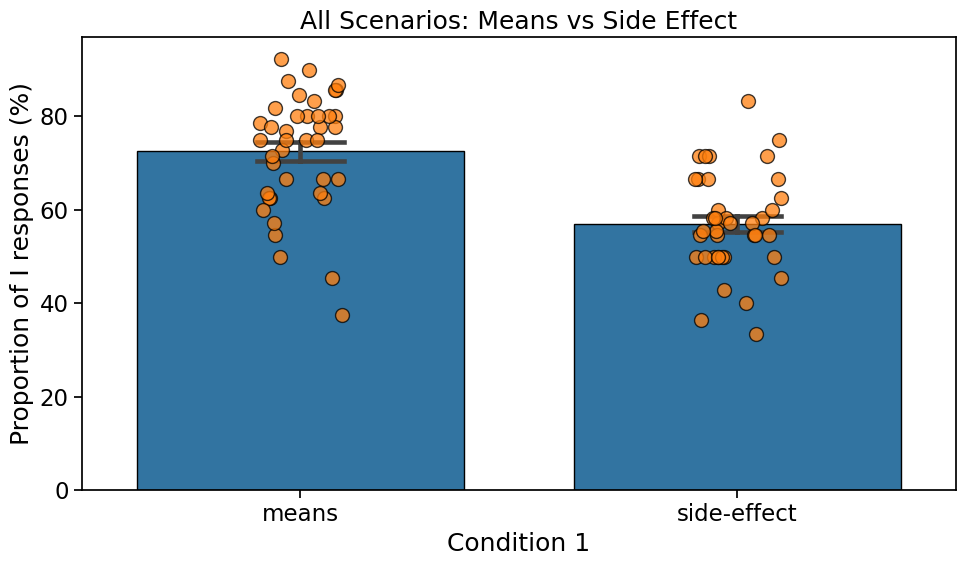

In [149]:
#collapsing across all conditions
generic_analysis_utils.plot_bar_strip(all_df, x= "condition_1", y= "prop_I", ylabel= "Proportion of I responses (%)", title="All Scenarios: Means vs Side Effect")

In [150]:
#show means by condition
print("Means by condition:")
print(all_df.groupby("condition_1")["prop_I"].mean())
#run a t-test comparing these conditions
result = ttest_ind(all_df[all_df["condition_1"] == "means"]["prop_I"], all_df[all_df["condition_1"] == "side-effect"]["prop_I"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

Means by condition:
condition_1
means          72.501727
side-effect    56.995581
Name: prop_I, dtype: float64
t(78.0): 6.026, p = 0.0000


### Analysis 1B -- Compare whether the primary harm event is labeled I+ more often in the CC than COC scenarios

**Hypothesis:** The CC group of scenarios should have more scenarios where the primary harm event is labelled I+ compared to COC

In [151]:
primary_harm_df = pd.read_csv("mild_FRANKEN_primary_harm_df.csv")

# add new columns for evitability and means_vs_sideeffect based on the causal_condition column
primary_harm_df["evitability"] = primary_harm_df["causal_condition"].apply(lambda x: "evitable" if "_evitable_" in x else "inevitable" if "_inevitable_" in x else "unknown")
primary_harm_df["means_vs_sideeffect"] = primary_harm_df["causal_condition"].apply(lambda x: "means" if "cc_" in x else "sideeffect" if "coc_" in x else "unknown")

def pm_list_to_int_list(cell):
    if isinstance(cell, str):
        cell = re.sub(r"\bnan\b", "'nan'", cell)
        cell = ast.literal_eval(cell)
    return [1 if v == "+" else 0 if v == "-" else np.nan for v in cell]

for col in ["C", "I", "K"]:
    primary_harm_df[col] = primary_harm_df[col].apply(pm_list_to_int_list)

primary_harm_df.head(1)

,SID,intensity,causal_condition,scenario_text,events,picked_event,picked_event_idx,option,being,C,I,K,utility,deontic,avg_permissibility_rating,avg_intention_rating,evitability,means_vs_sideeffect
0,0,mild_harm_mild_good,cc_evitable_action_yes_stories,"I, an Architect, face a moral dilemma. I have ...","['The park closes temporarily', 'Residents los...",Residents lose access to the recreational spac...,1.0,1: renovate the park.,i,"[1, 1, 1, 1, 1]","[1, 1, 0, 0, 1]","[1, 1, 1, 1, 1]",[{'residents of the community who use or value...,0.0,3.961538,2.269231,evitable,means


In [152]:
# Pull the scalar I label for just the primary/picked harm event out of the per-event "I" list
primary_harm_df["picked_event_idx"] = primary_harm_df["picked_event_idx"].astype(int)
primary_harm_df["I_primary"] = primary_harm_df.apply(lambda row: row["I"][row["picked_event_idx"]], axis=1)

condition_pairs_cc_coc = [
    ("cc_evitable_action_yes_stories",    "coc_evitable_action_yes_stories",    "evitable_action_yes"),
    ("cc_evitable_prevention_no_stories", "coc_evitable_prevention_no_stories", "evitable_prevention_no"),
    ("cc_inevitable_action_yes_stories",  "coc_inevitable_action_yes_stories",  "inevitable_action_yes"),
    ("cc_inevitable_prevention_no_stories","coc_inevitable_prevention_no_stories","inevitable_prevention_no"),
]

panels = []
for cond_a, cond_b, panel_title in condition_pairs_cc_coc:
    for cond, label in [(cond_a, "means"), (cond_b, "side-effect")]:
        sub = primary_harm_df[primary_harm_df["causal_condition"] == cond]
        panels.append(pd.DataFrame({
            "SID": sub["SID"].values,
            "I_primary": sub["I_primary"].values,
            "condition_1": label,
            "condition_2": panel_title,
        }))
A1B_df = pd.concat(panels, ignore_index=True)
A1B_df

,SID,I_primary,condition_1,condition_2
0,0,1,means,evitable_action_yes
1,1,0,means,evitable_action_yes
2,2,1,means,evitable_action_yes
3,3,0,means,evitable_action_yes
4,4,0,means,evitable_action_yes
...,...,...,...,...
75,5,0,side-effect,inevitable_prevention_no
76,6,0,side-effect,inevitable_prevention_no
77,7,0,side-effect,inevitable_prevention_no
78,8,0,side-effect,inevitable_prevention_no


In [153]:
# Stats: % I+ on the primary harm event, CC vs COC, per condition_2 panel and overall.

def fisher_stats(df):
    cc  = df[df["condition_1"] == "means"]["I_primary"]
    coc = df[df["condition_1"] == "side-effect"]["I_primary"]
    table = [[len(cc) - cc.sum(), cc.sum()], [len(coc) - coc.sum(), coc.sum()]] # I+ is 1 and I- is 0, so sum() gives the count of I+ and len() - sum() gives the count of I-
    _, p_val = fisher_exact(table)
    return {"n_cc": len(cc), "n_coc": len(coc), "pct_cc": 100 * cc.mean(), "pct_coc": 100 * coc.mean(), "p_value": p_val}

A1B_stats_df = pd.DataFrame(
    [{"condition_2": panel_title, **fisher_stats(A1B_df[A1B_df["condition_2"] == panel_title])}
     for panel_title in A1B_df["condition_2"].unique()]
    + [{"condition_2": "Overall", **fisher_stats(A1B_df)}]
)
A1B_stats_df

,condition_2,n_cc,n_coc,pct_cc,pct_coc,p_value
0,evitable_action_yes,10,10,40.0,0.0,0.086687
1,evitable_prevention_no,10,10,60.0,0.0,0.010836
2,inevitable_action_yes,10,10,10.0,0.0,1.000000
3,inevitable_prevention_no,10,10,20.0,10.0,1.000000
4,Overall,40,40,32.5,2.5,0.000669


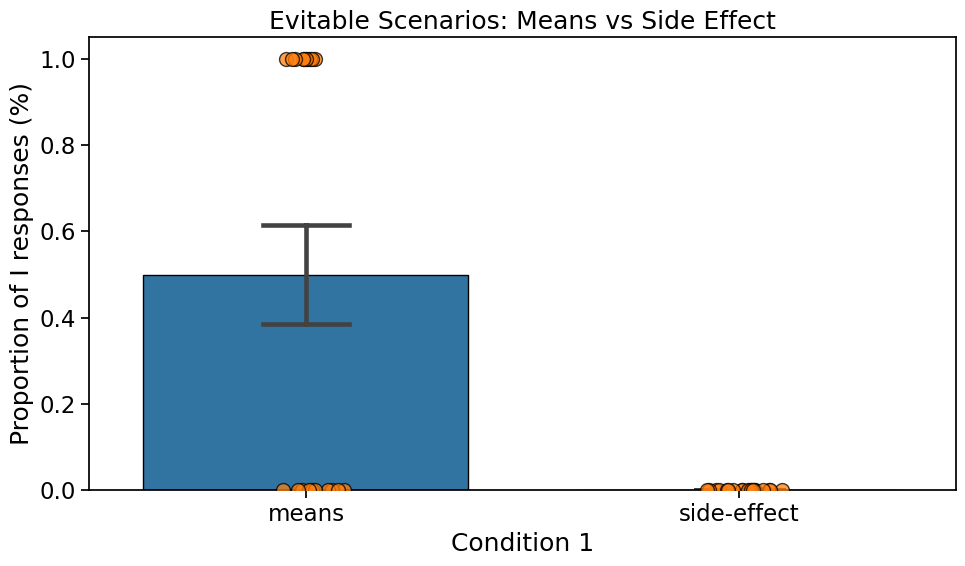

In [154]:
this_df = A1B_df[(A1B_df["condition_2"] == "evitable_action_yes") | (A1B_df["condition_2"] == "evitable_prevention_no")]
generic_analysis_utils.plot_bar_strip(this_df, x= "condition_1", y= "I_primary", ylabel= "Proportion of I responses (%)", title="Evitable Scenarios: Means vs Side Effect")

In [155]:
#run a t-test comparing these conditions
result = ttest_ind(this_df[this_df["condition_1"] == "means"]["I_primary"], this_df[this_df["condition_1"] == "side-effect"]["I_primary"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

t(38.0): 4.359, p = 0.0001


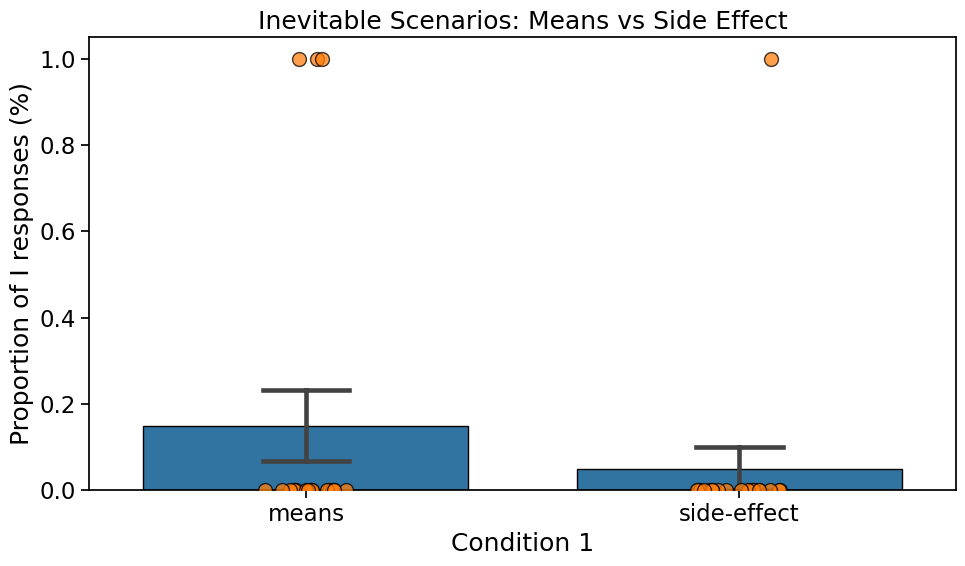

In [156]:
this_df = A1B_df[(A1B_df["condition_2"] == "inevitable_action_yes") | (A1B_df["condition_2"] == "inevitable_prevention_no")]
generic_analysis_utils.plot_bar_strip(this_df, x= "condition_1", y= "I_primary", ylabel= "Proportion of I responses (%)", title="Inevitable Scenarios: Means vs Side Effect")

In [157]:
#run a t-test comparing these conditions
result = ttest_ind(this_df[this_df["condition_1"] == "means"]["I_primary"], this_df[this_df["condition_1"] == "side-effect"]["I_primary"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

t(38.0): 1.042, p = 0.3040


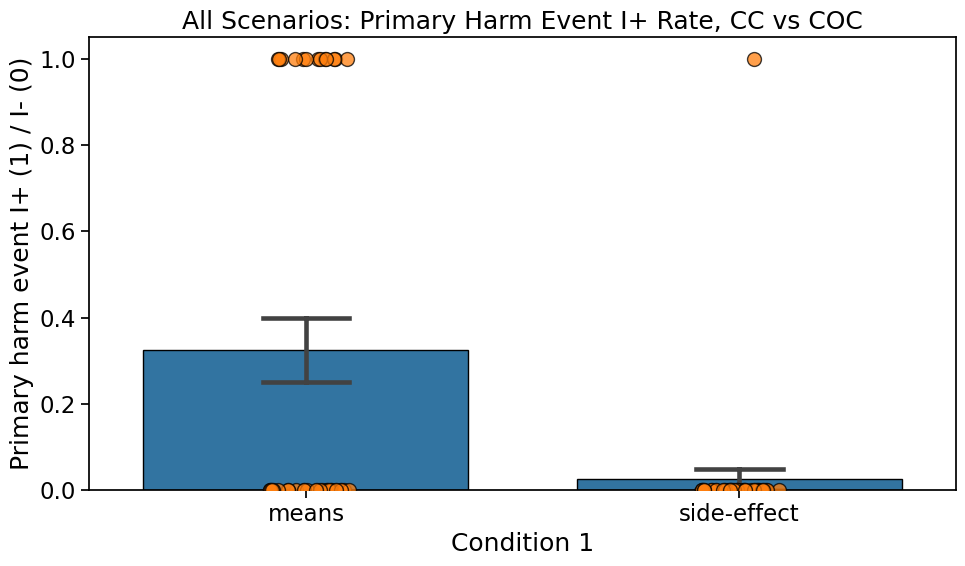

In [158]:
#collapsing across all conditions -- same pattern as Analysis 1A
generic_analysis_utils.plot_bar_strip(A1B_df, x="condition_1", y="I_primary", ylabel="Primary harm event I+ (1) / I- (0)", title="All Scenarios: Primary Harm Event I+ Rate, CC vs COC")

In [159]:
print("Means by condition:")
print(A1B_df.groupby("condition_1")["I_primary"].mean())
overall_stats = A1B_stats_df[A1B_stats_df["condition_2"] == "Overall"].iloc[0]
print(f"Fisher's exact test: p = {overall_stats.p_value:.4f}")

Means by condition:
condition_1
means          0.325
side-effect    0.025
Name: I_primary, dtype: float64
Fisher's exact test: p = 0.0007


## Analysis 2 -- Compare Evitable vs Inevitable scenarios on Causality Labels
Compare the per-scenario proportion of "C+" events between Evitable and Inevitable counterparts of the causal conditions (also checking overall across all)
**hypothesis** Evitable scenarios should have more events with more "control" over the outcome than inevitable, i.e. get more C+'s than inevitable scenarios.
Same scenario-level, paired-by-SID improvement as Analysis 1 (paired here by SID x causal_structure x action, varying only evitability).

In [160]:
all_FRANKEN_df.groupby(["evitability"])["C"].mean()

evitability
evitable      0.997326
inevitable    0.576316
Name: C, dtype: float64

In [161]:
#construct a dataframe with all the relevant data

condition_pairs_evit_inevit = [
    ("cc_evitable_action_yes_stories",     "cc_inevitable_action_yes_stories" ),
    ("cc_evitable_prevention_no_stories",  "cc_inevitable_prevention_no_stories" ),
    ("coc_evitable_action_yes_stories",    "coc_inevitable_action_yes_stories"  ),
    ("coc_evitable_prevention_no_stories", "coc_inevitable_prevention_no_stories"),
]
all_df_a2 =  pd.DataFrame()
for cond_a, cond_b in condition_pairs_evit_inevit:

    this_subset_a = all_FRANKEN_df[all_FRANKEN_df['causal_condition'] == cond_a]
    this_condition_a = this_subset_a['means_vs_sideeffect'].unique()
    assert(len(this_condition_a) == 1)
    causal_ratings_a = this_subset_a.groupby(['SID'])['C'].mean()
    causal_ratings_a = causal_ratings_a.reset_index().rename(columns={"SID": "SID", "C": "causality"})


    this_subset_b = all_FRANKEN_df[all_FRANKEN_df['causal_condition'] == cond_b]
    this_condition_b = this_subset_b['means_vs_sideeffect'].unique()
    assert(len(this_condition_b) == 1)
    causal_ratings_b = this_subset_b.groupby(['SID'])['C'].mean()
    causal_ratings_b = causal_ratings_b.reset_index().rename(columns={"SID": "SID", "C": "causality"})

    assert(causal_ratings_a["SID"].equals(causal_ratings_b["SID"]))

    data_a = pd.DataFrame({
        "prop_C": causal_ratings_a["causality"].values,
        "causality": this_condition_a[0],
        "sid":causal_ratings_a["SID"].values,
        "evitability":"evitable"
    })
    data_b = pd.DataFrame({
            "prop_C": causal_ratings_b["causality"].values,
            "causality": this_condition_b[0],
            "sid":causal_ratings_b["SID"].values,
            "evitability":"inevitable"
    })
    all_df_a2  = pd.concat([all_df_a2, data_a, data_b], ignore_index=True)


In [162]:
all_df_a2

,prop_C,causality,sid,evitability
0,1.000000,means,0,evitable
1,1.000000,means,1,evitable
2,1.000000,means,2,evitable
3,1.000000,means,3,evitable
4,1.000000,means,4,evitable
...,...,...,...,...
75,0.583333,sideeffect,5,inevitable
76,0.800000,sideeffect,6,inevitable
77,0.571429,sideeffect,7,inevitable
78,0.571429,sideeffect,8,inevitable


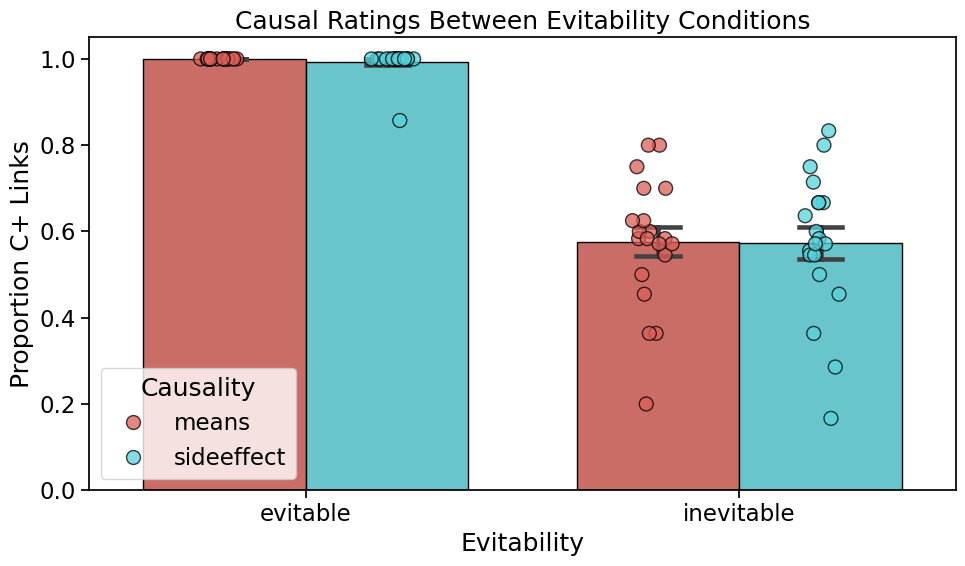

In [163]:
generic_analysis_utils.plot_bar_strip(all_df_a2, x= "evitability", y= "prop_C", hue="causality", ylabel= "Proportion C+ Links", title="Causal Ratings Between Evitability Conditions")

## Analysis 3 -- Do scenarios labeled intentional by the annotator get rated as more intentional by humans?

Humans rated intentionality on a SCENARIO-level, annotator gives "I" labels on an EVENT-level. 
We split the scenarios into I+ and I- groups based on the HAND-PICKED HARM EVENT (stored in `mild_FRANKEN_primary_harm_df.csv`) and compare the avg human intentionality rating given to each group -- we would like to see a significant difference in avg. human rating between the two.

In [165]:

qualitative_scenario_df = primary_harm_df.dropna(subset=["avg_intention_rating"]).copy()
qualitative_scenario_df["I_binary"] = qualitative_scenario_df["I_primary"]
qualitative_scenario_df["I_label"]  = qualitative_scenario_df["I_primary"].map({1: "I+", 0: "I-"})
print(f"Qualitative pick DF: {len(qualitative_scenario_df)} rows | "
      f"I+: {(qualitative_scenario_df['I_binary'] == 1).sum()}, I-: {(qualitative_scenario_df['I_binary'] == 0).sum()}")

Qualitative pick DF: 80 rows | I+: 14, I-: 66


In [166]:
qualitative_scenario_df.groupby(["I_binary","means_vs_sideeffect","evitability"])["avg_intention_rating"].mean().reset_index()

,I_binary,means_vs_sideeffect,evitability,avg_intention_rating
0,0,means,evitable,2.469292
1,0,means,inevitable,2.078681
2,0,sideeffect,evitable,2.244616
3,0,sideeffect,inevitable,1.958030
4,1,means,evitable,2.510870
5,1,means,inevitable,2.247364
6,1,sideeffect,inevitable,1.923077


In [167]:
qualitative_scenario_df.groupby(["I_binary"])["avg_intention_rating"].mean().reset_index()

,I_binary,avg_intention_rating
0,0,2.153415
1,1,2.412419


In [168]:
qualitative_scenario_df.groupby(["means_vs_sideeffect"])["avg_intention_rating"].mean().reset_index()

,means_vs_sideeffect,avg_intention_rating
0,means,2.297032
1,sideeffect,2.100449


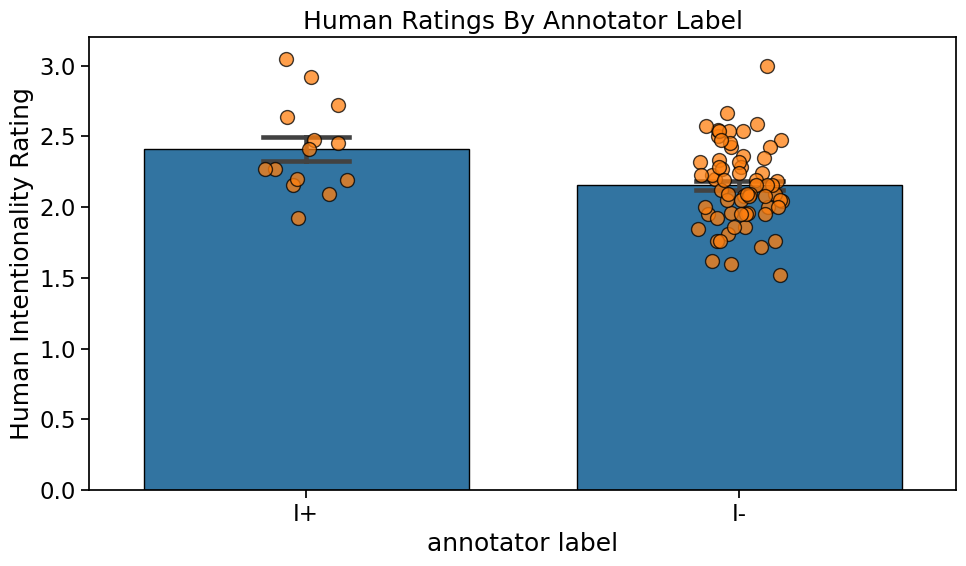

In [169]:
generic_analysis_utils.plot_bar_strip(qualitative_scenario_df, x= "I_label", y= "avg_intention_rating", xlabel = "annotator label", ylabel= "Human Intentionality Rating",title="Human Ratings By Annotator Label")

In [170]:
#run a t-test comparing these groups -- same pattern as Analysis 1A
result = ttest_ind(qualitative_scenario_df[qualitative_scenario_df["I_binary"] == 1]["avg_intention_rating"],
                    qualitative_scenario_df[qualitative_scenario_df["I_binary"] == 0]["avg_intention_rating"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

t(78.0): 3.029, p = 0.0033


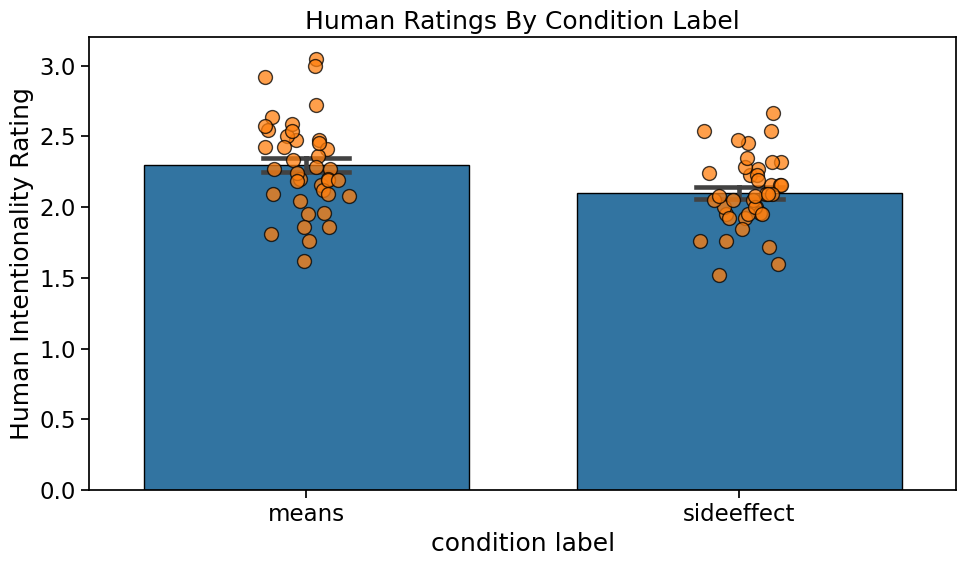

In [171]:
generic_analysis_utils.plot_bar_strip(qualitative_scenario_df, x= "means_vs_sideeffect", y= "avg_intention_rating", xlabel = "condition label", ylabel= "Human Intentionality Rating",title="Human Ratings By Condition Label")

In [172]:
#run a t-test comparing these groups -- same pattern as Analysis 1A
result = ttest_ind(qualitative_scenario_df[qualitative_scenario_df["means_vs_sideeffect"] == "means"]["avg_intention_rating"],
                    qualitative_scenario_df[qualitative_scenario_df["means_vs_sideeffect"] == "sideeffect"]["avg_intention_rating"])
print(f"t({result.df}): {result.statistic:.3f}, p = {result.pvalue:.4f}")

t(78.0): 3.025, p = 0.0034
